# `test_run_001.arrow` frame data 확인

이 노트북은 `/home/carol/chaeyeon-kim/processed/test_run_001.arrow` 파일에서 `frame` 열과 그 안의 `data` 정보를 확인합니다.

파일이 약 2.7GB라서 전체를 pandas DataFrame으로 바로 변환하지 않고, schema와 일부 row만 읽도록 구성했습니다.

In [1]:
# 필요한 패키지가 없다면 아래 셀을 실행하세요.
# 설치 후에는 커널을 재시작하는 것이 안전합니다.

try:
    import pyarrow as pa
    import pyarrow.ipc as ipc
    print('pyarrow:', pa.__version__)
except ModuleNotFoundError:
    print('pyarrow가 설치되어 있지 않습니다. 다음 명령을 실행한 뒤 커널을 재시작하세요:')
    print('%pip install pyarrow pandas pillow matplotlib')

pyarrow: 17.0.0


In [2]:
from pathlib import Path
import io
import json

import pyarrow as pa
import pyarrow.ipc as ipc
from IPython.display import display

ARROW_PATH = Path('/home/carol/chaeyeon-kim/processed/test_run_001.arrow')

print('exists:', ARROW_PATH.exists())
print('size GB:', round(ARROW_PATH.stat().st_size / 1024**3, 2))

exists: True
size GB: 2.54


## Arrow reader 열기

Arrow 파일은 file format 또는 stream format일 수 있어서 둘 다 시도합니다.

In [3]:
def open_arrow_reader(path):
    source = pa.memory_map(str(path), 'r')
    try:
        reader = ipc.open_file(source)
        return source, reader, 'file'
    except pa.ArrowInvalid:
        source.close()
        source = pa.memory_map(str(path), 'r')
        reader = ipc.open_stream(source)
        return source, reader, 'stream'

source, reader, arrow_kind = open_arrow_reader(ARROW_PATH)
print('arrow kind:', arrow_kind)
print(reader.schema)

arrow kind: stream
run_id: string
frame: int32
timestamp: float
image_front: struct<bytes: binary, path: string>
  child 0, bytes: binary
  child 1, path: string
lidar: list<item: list<item: float>>
  child 0, item: list<item: float>
      child 0, item: float
steer: float
throttle: float
speed_kmh: float
-- schema metadata --
huggingface: '{"info": {"features": {"run_id": {"dtype": "string", "_type' + 1954


In [4]:
schema = reader.schema
print('columns:', schema.names)

if 'frame' not in schema.names:
    raise KeyError('frame column not found')

frame_field = schema.field('frame')
print('frame field:')
print(frame_field)
print('frame type:', frame_field.type)

columns: ['run_id', 'frame', 'timestamp', 'image_front', 'lidar', 'steer', 'throttle', 'speed_kmh']
frame field:
pyarrow.Field<frame: int32>
frame type: int32


## 첫 번째 batch와 `frame` 샘플 확인

In [5]:
def first_record_batch(reader):
    if hasattr(reader, 'get_batch'):
        return reader.get_batch(0)
    return next(reader)

batch = first_record_batch(reader)
print('batch rows:', batch.num_rows)
print('batch columns:', batch.schema.names)

frame_array = batch.column(batch.schema.get_field_index('frame'))
print('frame array type:', frame_array.type)
print('frame null count:', frame_array.null_count)

batch rows: 100
batch columns: ['run_id', 'frame', 'timestamp', 'image_front', 'lidar', 'steer', 'throttle', 'speed_kmh']
frame array type: int32
frame null count: 0


In [6]:
def summarize_value(value, max_bytes=64, max_items=5):
    if isinstance(value, dict):
        return {k: summarize_value(v, max_bytes=max_bytes, max_items=max_items) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return {
            'python_type': type(value).__name__,
            'length': len(value),
            'sample': [summarize_value(v, max_bytes=max_bytes, max_items=max_items) for v in value[:max_items]],
        }
    if isinstance(value, (bytes, bytearray)):
        return {
            'python_type': type(value).__name__,
            'length_bytes': len(value),
            'first_bytes_hex': bytes(value[:max_bytes]).hex(),
        }
    return {
        'python_type': type(value).__name__,
        'repr': repr(value)[:500],
    }

sample_count = min(5, len(frame_array))
frame_samples = [frame_array[i].as_py() for i in range(sample_count)]

for i, value in enumerate(frame_samples):
    print(f'--- frame sample {i} ---')
    print(json.dumps(summarize_value(value), ensure_ascii=False, indent=2)[:4000])

--- frame sample 0 ---
{
  "python_type": "int",
  "repr": "0"
}
--- frame sample 1 ---
{
  "python_type": "int",
  "repr": "5"
}
--- frame sample 2 ---
{
  "python_type": "int",
  "repr": "10"
}
--- frame sample 3 ---
{
  "python_type": "int",
  "repr": "15"
}
--- frame sample 4 ---
{
  "python_type": "int",
  "repr": "20"
}


## `frame['data']`만 따로 확인

`frame`이 struct/dict 형태라면 `data` 필드를 추출합니다.

In [7]:
def extract_frame_data(frame_value):
    if isinstance(frame_value, dict):
        return frame_value.get('data')
    return None

data_samples = [extract_frame_data(value) for value in frame_samples]

for i, data in enumerate(data_samples):
    print(f'--- frame["data"] sample {i} ---')
    print(json.dumps(summarize_value(data), ensure_ascii=False, indent=2)[:4000])

--- frame["data"] sample 0 ---
{
  "python_type": "NoneType",
  "repr": "None"
}
--- frame["data"] sample 1 ---
{
  "python_type": "NoneType",
  "repr": "None"
}
--- frame["data"] sample 2 ---
{
  "python_type": "NoneType",
  "repr": "None"
}
--- frame["data"] sample 3 ---
{
  "python_type": "NoneType",
  "repr": "None"
}
--- frame["data"] sample 4 ---
{
  "python_type": "NoneType",
  "repr": "None"
}


## `data`가 이미지 bytes인지 확인해서 표시

`frame['data']`가 PNG/JPEG 같은 이미지 bytes라면 아래 셀에서 미리보기를 표시합니다.

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

def try_display_image_bytes(data):
    if not isinstance(data, (bytes, bytearray)):
        print('data is not bytes:', type(data).__name__)
        return None
    try:
        image = Image.open(io.BytesIO(data))
    except Exception as exc:
        print('not decodable as image:', repr(exc))
        return None

    print('image format:', image.format)
    print('image size:', image.size)
    print('image mode:', image.mode)
    display(image)
    return image

for i, data in enumerate(data_samples):
    print(f'--- image preview sample {i} ---')
    image = try_display_image_bytes(data)
    if image is not None:
        break

--- image preview sample 0 ---
data is not bytes: NoneType
--- image preview sample 1 ---
data is not bytes: NoneType
--- image preview sample 2 ---
data is not bytes: NoneType
--- image preview sample 3 ---
data is not bytes: NoneType
--- image preview sample 4 ---
data is not bytes: NoneType


## 여러 row의 `data` 길이 통계

처음 몇 개 batch만 훑어서 `frame['data']`의 bytes 길이를 확인합니다. 필요하면 `MAX_BATCHES` 값을 늘리세요.

In [9]:
import pandas as pd

MAX_BATCHES = 3
records = []

source2, reader2, arrow_kind2 = open_arrow_reader(ARROW_PATH)

try:
    if hasattr(reader2, 'num_record_batches'):
        batch_iter = (reader2.get_batch(i) for i in range(min(MAX_BATCHES, reader2.num_record_batches)))
    else:
        batch_iter = reader2

    for batch_idx, current_batch in enumerate(batch_iter):
        if batch_idx >= MAX_BATCHES:
            break
        current_frame = current_batch.column(current_batch.schema.get_field_index('frame'))
        for row_idx in range(len(current_frame)):
            frame_value = current_frame[row_idx].as_py()
            data = extract_frame_data(frame_value)
            records.append({
                'batch_idx': batch_idx,
                'row_idx': row_idx,
                'frame_type': type(frame_value).__name__,
                'data_type': type(data).__name__,
                'data_len': len(data) if hasattr(data, '__len__') else None,
            })
finally:
    source2.close()

df = pd.DataFrame(records)
display(df.head(20))
display(df[['data_type', 'data_len']].describe(include='all'))

,batch_idx,row_idx,frame_type,data_type,data_len
0,0,0,int,NoneType,None
1,0,1,int,NoneType,None
2,0,2,int,NoneType,None
3,0,3,int,NoneType,None
4,0,4,int,NoneType,None
5,0,5,int,NoneType,None
6,0,6,int,NoneType,None
7,0,7,int,NoneType,None
8,0,8,int,NoneType,None
9,0,9,int,NoneType,None


,data_type,data_len
count,213,0
unique,1,0
top,NoneType,NaN
freq,213,NaN


## Arrow 파일 전체를 pandas DataFrame으로 변환해서 `df.info()` 확인

아래 셀은 Arrow 파일 전체를 메모리에 올립니다. 파일 크기가 약 2.7GB이므로 pandas 변환 후 실제 메모리 사용량은 더 커질 수 있습니다. 커널이 죽거나 `MemoryError`가 나면 batch 방식으로 확인해야 합니다.

In [10]:
import pandas as pd

# 전체 로딩을 정말 실행하려면 True로 바꾸세요.
RUN_FULL_LOAD = True

if not RUN_FULL_LOAD:
    print('RUN_FULL_LOAD = True 로 바꾼 뒤 실행하면 전체 Arrow 파일을 df로 변환합니다.')
else:
    source_full, reader_full, arrow_kind_full = open_arrow_reader(ARROW_PATH)
    try:
        table_full = reader_full.read_all()
        print('arrow kind:', arrow_kind_full)
        print('table rows:', table_full.num_rows)
        print('table columns:', table_full.num_columns)
        print('table nbytes GB:', round(table_full.nbytes / 1024**3, 2))

        df_full = table_full.to_pandas()
    finally:
        source_full.close()

    print('df shape:', df_full.shape)
    df_full.info(memory_usage='deep')
    display(df_full.head())

arrow kind: stream
table rows: 2400
table columns: 8
table nbytes GB: 2.54
df shape: (2400, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   run_id       2400 non-null   object 
 1   frame        2400 non-null   int32  
 2   timestamp    2400 non-null   float32
 3   image_front  2400 non-null   object 
 4   lidar        2400 non-null   object 
 5   steer        2400 non-null   float32
 6   throttle     2400 non-null   float32
 7   speed_kmh    2400 non-null   float32
dtypes: float32(4), int32(1), object(3)
memory usage: 1003.2 KB


,run_id,frame,timestamp,image_front,lidar,steer,throttle,speed_kmh
0,run_001,0,1.712961,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,"[[-74.34138, 1.873559e-12, 13.108391, 0.739372...",-0.022482,0.85,10.693418
1,run_001,5,3.010729,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,"[[-74.87856, 1.8371793e-12, 13.203112, 0.73776...",-0.023323,0.85,6.757796
2,run_001,10,4.285059,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,"[[-75.29838, 1.873559e-12, 13.277136, 0.736504...",-0.024505,0.00,1.802249
3,run_001,15,5.553712,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,"[[-75.24126, 1.7826095e-12, 13.267064, 0.73667...",-0.024624,0.00,0.073133
4,run_001,20,6.853644,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,"[[-75.205154, 1.8189894e-12, 13.260697, 0.7367...",-0.024568,0.00,0.000000


## 전체 DataFrame 분포 요약

위 셀에서 `df_full`을 만든 뒤 실행하세요.

In [11]:
if 'df_full' not in globals():
    print('먼저 위 셀에서 RUN_FULL_LOAD = True 로 바꾸고 df_full을 생성하세요.')
else:
    def safe_nunique(series):
        try:
            return series.nunique(dropna=True)
        except TypeError:
            # dict/list/ndarray처럼 hash 불가능한 값은 문자열 표현 기준으로 대략적인 unique 수를 봅니다.
            return series.dropna().map(lambda x: repr(x)).nunique()

    summary = pd.DataFrame({
        'dtype': df_full.dtypes.astype(str),
        'non_null': df_full.notna().sum(),
        'null': df_full.isna().sum(),
        'null_ratio': df_full.isna().mean(),
        'nunique_safe': [safe_nunique(df_full[col]) for col in df_full.columns],
    }, index=df_full.columns)
    display(summary)

    print('numeric columns describe:')
    display(df_full.describe())

    print('non-numeric columns describe, excluding nested dict/list columns:')
    simple_object_cols = []
    for col in df_full.select_dtypes(include='object').columns:
        sample = df_full[col].dropna().head(100)
        if sample.map(lambda x: isinstance(x, (dict, list, tuple, set))).any():
            print(f'skip nested object column: {col}')
        else:
            simple_object_cols.append(col)

    if simple_object_cols:
        display(df_full[simple_object_cols].describe(include='all'))
    else:
        print('describe 가능한 단순 object 컬럼이 없습니다.')


,dtype,non_null,null,null_ratio,nunique_safe
run_id,object,2400,0,0.0,1
frame,int32,2400,0,0.0,2400
timestamp,float32,2400,0,0.0,2400
image_front,object,2400,0,0.0,2400
lidar,object,2400,0,0.0,2305
steer,float32,2400,0,0.0,1331
throttle,float32,2400,0,0.0,925
speed_kmh,float32,2400,0,0.0,1340


numeric columns describe:


,frame,timestamp,steer,throttle,speed_kmh
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,5997.500000,1520.509399,0.032521,0.089980,14.314655
std,3464.823228,878.586609,0.141997,0.189947,13.850399
min,0.000000,1.712961,-0.570064,0.000000,0.000000
25%,2998.750000,759.935379,-0.024568,0.000000,0.000000
50%,5997.500000,1518.774170,0.000000,0.000000,15.449342
75%,8996.250000,2282.679016,0.035438,0.104934,29.694323
max,11995.000000,3039.713867,0.800000,0.850000,29.891743


non-numeric columns describe, excluding nested dict/list columns:
skip nested object column: image_front


,run_id,lidar
count,2400,2400
unique,1,2400
top,run_001,"[[-74.34138, 1.873559e-12, 13.108391, 0.739372..."
freq,2400,1


## 전체 DataFrame에서 `frame` 컬럼 자세히 보기

In [12]:
if 'df_full' not in globals():
    print('먼저 df_full을 생성하세요.')
elif 'frame' not in df_full.columns:
    print('df_full에 frame 컬럼이 없습니다.')
else:
    frame_series = df_full['frame']
    print('frame dtype:', frame_series.dtype)
    print('frame null count:', frame_series.isna().sum())
    print('frame python type counts:')
    display(frame_series.map(lambda x: type(x).__name__).value_counts(dropna=False))

    print('frame samples:')
    for idx, value in frame_series.head(5).items():
        print(f'--- index {idx} ---')
        print(json.dumps(summarize_value(value), ensure_ascii=False, indent=2)[:4000])

    if frame_series.map(lambda x: isinstance(x, dict)).any():
        frame_keys = sorted({
            key
            for value in frame_series.dropna().head(1000)
            if isinstance(value, dict)
            for key in value.keys()
        })
        print('frame keys found in first 1000 non-null rows:', frame_keys)
        frame_normalized = pd.json_normalize(frame_series.dropna().head(1000))
        display(frame_normalized.head())
        display(frame_normalized.dtypes.astype(str).to_frame('dtype'))

frame dtype: int32
frame null count: 0
frame python type counts:


frame
int    2400
Name: count, dtype: int64

frame samples:
--- index 0 ---
{
  "python_type": "int",
  "repr": "0"
}
--- index 1 ---
{
  "python_type": "int",
  "repr": "5"
}
--- index 2 ---
{
  "python_type": "int",
  "repr": "10"
}
--- index 3 ---
{
  "python_type": "int",
  "repr": "15"
}
--- index 4 ---
{
  "python_type": "int",
  "repr": "20"
}


## Timestamp 간격으로 20Hz 여부 확인

20Hz라면 연속 timestamp 간격이 약 `0.05초`입니다. 아래 셀은 timestamp로 보이는 컬럼을 찾고, 전체 DataFrame이 있으면 `df_full`에서 바로 분석합니다. `df_full`이 없으면 Arrow batch에서 timestamp 컬럼만 읽어서 분석합니다.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXPECTED_HZ = 20
EXPECTED_DT_SECONDS = 1 / EXPECTED_HZ
TOLERANCE_SECONDS = 0.005  # 5ms 허용 오차. 필요하면 조정하세요.

# 컬럼 이름이 다를 수 있어서 후보를 자동으로 찾습니다.
time_candidates = [
    name for name in schema.names
    if any(token in name.lower() for token in ['timestamp', 'time', 'stamp', 'ts'])
]
print('time-like columns:', time_candidates)

# 원하는 컬럼이 따로 있으면 여기에 직접 넣으세요. 예: TIMESTAMP_COL = 'timestamp'
TIMESTAMP_COL = time_candidates[0] if time_candidates else None
print('selected TIMESTAMP_COL:', TIMESTAMP_COL)

if TIMESTAMP_COL is None:
    raise KeyError('timestamp/time 계열 컬럼을 찾지 못했습니다. schema.names를 보고 TIMESTAMP_COL을 직접 지정하세요.')

time-like columns: ['timestamp']
selected TIMESTAMP_COL: timestamp


In [14]:
def collect_timestamp_series(timestamp_col, max_batches=None):
    if 'df_full' in globals() and timestamp_col in df_full.columns:
        print('using df_full')
        return df_full[timestamp_col].copy()

    print('df_full이 없어서 Arrow에서 timestamp 컬럼만 읽습니다.')
    values = []
    source_ts, reader_ts, _ = open_arrow_reader(ARROW_PATH)
    try:
        if hasattr(reader_ts, 'num_record_batches'):
            total_batches = reader_ts.num_record_batches
            if max_batches is not None:
                total_batches = min(total_batches, max_batches)
            batch_iter = (reader_ts.get_batch(i) for i in range(total_batches))
        else:
            batch_iter = reader_ts

        for batch_idx, current_batch in enumerate(batch_iter):
            if max_batches is not None and batch_idx >= max_batches:
                break
            col_idx = current_batch.schema.get_field_index(timestamp_col)
            if col_idx < 0:
                raise KeyError(f'{timestamp_col} column not found in batch')
            values.extend(current_batch.column(col_idx).to_pylist())
    finally:
        source_ts.close()

    return pd.Series(values, name=timestamp_col)

# 전체 timestamp를 읽습니다. 너무 느리면 max_batches=10처럼 제한하세요.
ts_raw = collect_timestamp_series(TIMESTAMP_COL, max_batches=None)
print('timestamp count:', len(ts_raw))
print('non-null count:', ts_raw.notna().sum())
display(ts_raw.head(10).to_frame())
print('raw dtype:', ts_raw.dtype)
print('python type counts:')
display(ts_raw.map(lambda x: type(x).__name__).value_counts(dropna=False))

using df_full
timestamp count: 2400
non-null count: 2400


,timestamp
0,1.712961
1,3.010729
2,4.285059
3,5.553712
4,6.853644
5,8.137531
6,9.438069
7,10.709364
8,11.950263
9,13.189825


raw dtype: float32
python type counts:


timestamp
float    2400
Name: count, dtype: int64

In [15]:
def normalize_timestamp_to_seconds(series):
    s = series.dropna().reset_index(drop=True)

    # pandas datetime이면 초 단위 float으로 변환합니다.
    if pd.api.types.is_datetime64_any_dtype(s):
        return s.astype('int64') / 1e9

    # 숫자 timestamp인 경우 단위를 추정합니다.
    numeric = pd.to_numeric(s, errors='coerce').dropna().reset_index(drop=True)
    if len(numeric) == 0:
        parsed = pd.to_datetime(s, errors='coerce').dropna().reset_index(drop=True)
        if len(parsed) == 0:
            raise ValueError('timestamp를 숫자 또는 datetime으로 변환할 수 없습니다.')
        return parsed.astype('int64') / 1e9

    diffs = numeric.diff().dropna().abs()
    median_raw_diff = diffs[diffs > 0].median()
    print('median raw diff:', median_raw_diff)

    # 20Hz 기준 raw diff를 보고 sec/ms/us/ns를 추정합니다.
    if pd.isna(median_raw_diff):
        scale = 1.0
        unit_guess = 'unknown'
    elif median_raw_diff > 10_000_000:
        scale = 1e9
        unit_guess = 'nanoseconds'
    elif median_raw_diff > 10_000:
        scale = 1e6
        unit_guess = 'microseconds'
    elif median_raw_diff > 10:
        scale = 1e3
        unit_guess = 'milliseconds'
    else:
        scale = 1.0
        unit_guess = 'seconds'

    print('unit guess:', unit_guess)
    return numeric / scale

ts_seconds = normalize_timestamp_to_seconds(ts_raw)
dt = ts_seconds.diff().dropna()
positive_dt = dt[dt > 0]

print('expected dt seconds:', EXPECTED_DT_SECONDS)
print('dt count:', len(dt))
print('positive dt count:', len(positive_dt))
print('non-positive dt count:', int((dt <= 0).sum()))

dt_summary = pd.Series({
    'mean_dt': dt.mean(),
    'median_dt': dt.median(),
    'std_dt': dt.std(),
    'min_dt': dt.min(),
    'max_dt': dt.max(),
    'mean_hz': 1 / dt.mean() if dt.mean() else np.nan,
    'median_hz': 1 / dt.median() if dt.median() else np.nan,
    'within_tolerance_ratio': ((dt - EXPECTED_DT_SECONDS).abs() <= TOLERANCE_SECONDS).mean(),
})
display(dt_summary.to_frame('value'))

display(dt.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame('dt_seconds'))

median raw diff: 1.262207
unit guess: seconds
expected dt seconds: 0.05
dt count: 2399
positive dt count: 2399
non-positive dt count: 0


,value
mean_dt,1.266361
median_dt,1.262207
std_dt,0.019861
min_dt,1.223389
max_dt,1.458801
mean_hz,0.789664
median_hz,0.792263
within_tolerance_ratio,0.000000


,dt_seconds
count,2399.000000
mean,1.266361
std,0.019861
min,1.223389
1%,1.236234
5%,1.242878
50%,1.262207
95%,1.301392
99%,1.335234
max,1.458801


In [16]:
# 20Hz에서 벗어난 구간 확인
bad_mask = (dt - EXPECTED_DT_SECONDS).abs() > TOLERANCE_SECONDS
bad_intervals = pd.DataFrame({
    'row_prev': dt.index[bad_mask] - 1,
    'row_curr': dt.index[bad_mask],
    'dt_seconds': dt[bad_mask].values,
    'hz': 1 / dt[bad_mask].values,
})

print('bad interval count:', len(bad_intervals))
print('bad interval ratio:', len(bad_intervals) / len(dt) if len(dt) else np.nan)
display(bad_intervals.head(50))

bad interval count: 2399
bad interval ratio: 1.0


,row_prev,row_curr,dt_seconds,hz
0,0,1,1.297768,0.770554
1,1,2,1.274330,0.784726
2,2,3,1.268653,0.788238
3,3,4,1.299932,0.769271
4,4,5,1.283887,0.778885
5,5,6,1.300538,0.768912
6,6,7,1.271295,0.786600
7,7,8,1.240899,0.805867
8,8,9,1.239562,0.806737
9,9,10,1.260204,0.793522


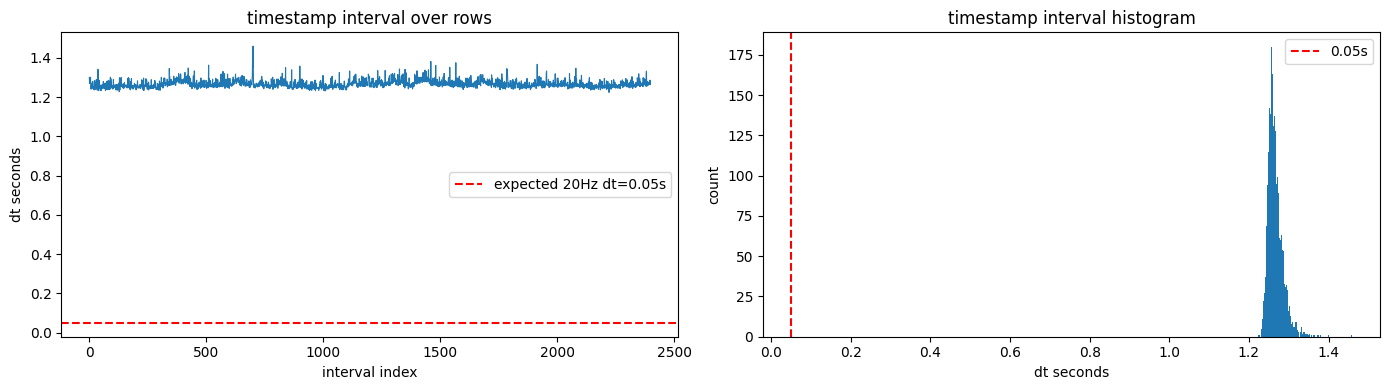

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(dt.reset_index(drop=True), linewidth=0.8)
axes[0].axhline(EXPECTED_DT_SECONDS, color='red', linestyle='--', label='expected 20Hz dt=0.05s')
axes[0].set_title('timestamp interval over rows')
axes[0].set_xlabel('interval index')
axes[0].set_ylabel('dt seconds')
axes[0].legend()

axes[1].hist(dt, bins=100)
axes[1].axvline(EXPECTED_DT_SECONDS, color='red', linestyle='--', label='0.05s')
axes[1].set_title('timestamp interval histogram')
axes[1].set_xlabel('dt seconds')
axes[1].set_ylabel('count')
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# 작업이 끝나면 메모리 매핑 핸들을 닫습니다.
source.close()